### Nacitanie dat z bytu

In [39]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# 1. Načítanie JSON súboru
with open("data.json", "r") as file:
    json_data = json.load(file)

# 2. Extrahovanie sekcie "data"
df = pd.json_normalize(json_data["data"])

# 3. Premenovanie stĺpcov pre lepšiu čitateľnosť
df.columns = df.columns.str.replace(r"\.", "_", regex=True)

# 4. Prevod timestampu na datetime formát
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# 5. Nastavenie časového indexu
df.set_index('timestamp', inplace=True)

# 6. Hodinová agregácia (napr. priemer)
df = df.resample('1h').mean()

# 7. Zobrazenie prvých riadkov z hodinovo agregovaných dát
print(df.tail())

                           U_L1      I_L1         P_L1        Q_L1
timestamp                                                         
2024-11-25 05:00:00  241.875683  1.899683   376.167333 -157.742150
2024-11-25 06:00:00  242.101150  2.517483   538.411867  -83.347750
2024-11-25 07:00:00  242.210167  1.812800   276.782950  110.196817
2024-11-25 08:00:00  241.571183  5.723533  1122.427583  380.538150
2024-11-25 09:00:00  241.406000  2.858000   363.827000  380.706000


### Nacitanie dat z domu

In [41]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# 1. Načítanie JSON súboru
with open("data2.json", "r") as file:
    json_data2 = json.load(file)

# 2. Extrahovanie sekcie "data"
df2 = pd.json_normalize(json_data2["data"])

# 3. Premenovanie stĺpcov pre lepšiu čitateľnosť
df2.columns = df2.columns.str.replace(r"\.", "_", regex=True)

# 4. Prevod timestampu na datetime formát
df2['timestamp'] = pd.to_datetime(df2['timestamp'], unit='s')

# 5. Nastavenie časového indexu
df2.set_index('timestamp', inplace=True)

# 6. Hodinová agregácia (napr. priemer)
df2 = df2.resample('1h').mean()

# 7. Zobrazenie prvých riadkov z hodinovo agregovaných dát
print(df2.tail())


                           U_L1        U_L2        U_L3  U_cumulative  \
timestamp                                                               
2024-11-25 05:00:00  243.024067  244.675467  235.729450    241.143050   
2024-11-25 06:00:00  245.241050  245.588800  239.173983    243.334667   
2024-11-25 07:00:00  245.807700  245.210783  241.104100    244.040817   
2024-11-25 08:00:00  243.456817  246.216533  240.537400    243.403633   
2024-11-25 09:00:00  244.010000  243.160000  238.323000    241.831000   

                         I_L1      I_L2      I_L3  I_cumulative       P_L1  \
timestamp                                                                    
2024-11-25 05:00:00  0.447417  0.378317  0.213667      1.039400  53.797383   
2024-11-25 06:00:00  0.422050  0.413767  0.149733      0.985550  42.064467   
2024-11-25 07:00:00  0.421483  0.358733  0.149550      0.929767  42.364467   
2024-11-25 08:00:00  0.418917  0.360300  0.304233      1.083450  41.936767   
2024-11-25 09:00:00 

### Vizualizacia bytu

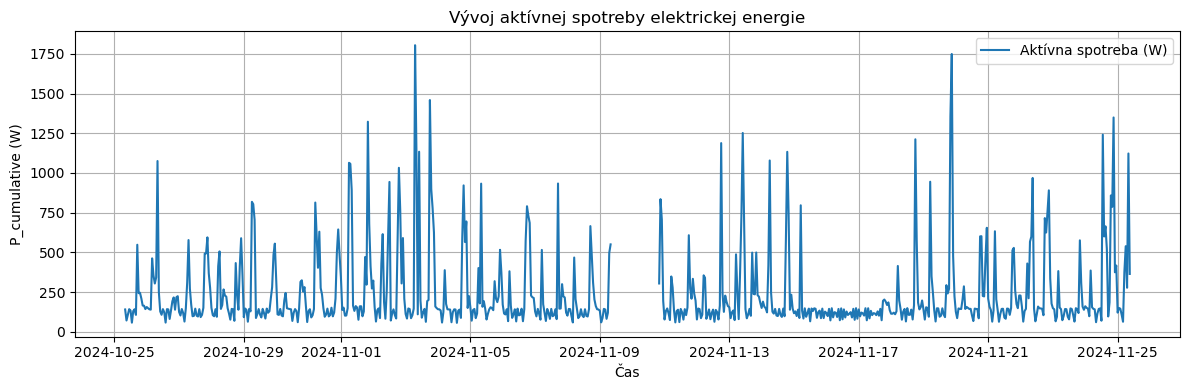

In [43]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['P_L1'], label='Aktívna spotreba (W)')
plt.title('Vývoj aktívnej spotreby elektrickej energie')
plt.xlabel('Čas')
plt.ylabel('P_cumulative (W)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Vizualizacia domu

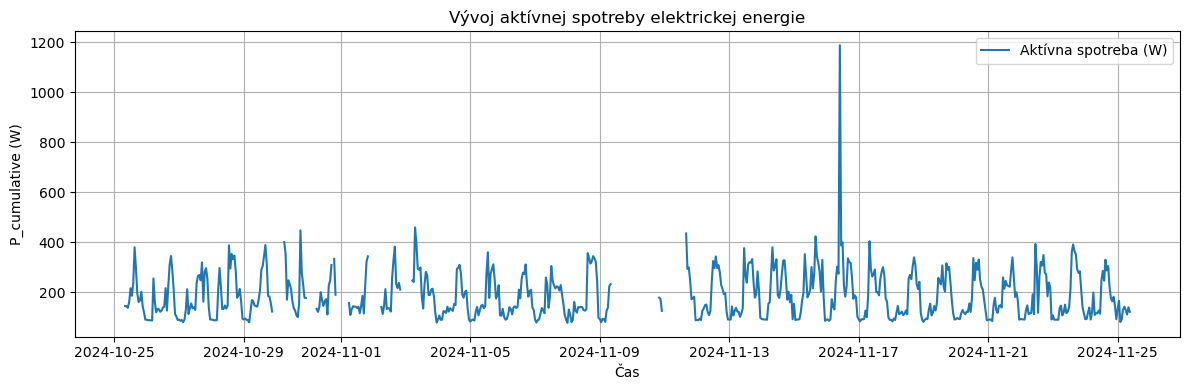

In [45]:
plt.figure(figsize=(12, 4))
plt.plot(df2.index, df2['P_cumulative'], label='Aktívna spotreba (W)')
plt.title('Vývoj aktívnej spotreby elektrickej energie')
plt.xlabel('Čas')
plt.ylabel('P_cumulative (W)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Vizualizacia oboch domacnosti

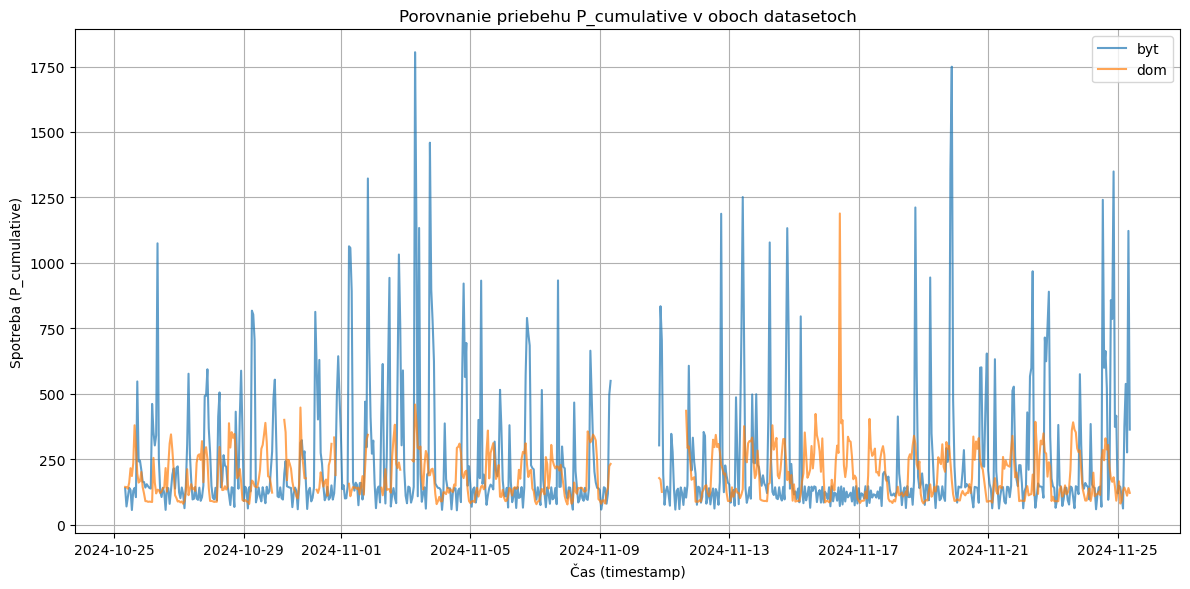

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))  #veľkosť grafu

# Prvý dataset
plt.plot(df.index, df['P_L1'], label='byt', alpha=0.7)

# Druhý dataset
plt.plot(df2.index, df2['P_cumulative'], label='dom', alpha=0.7)

plt.title('Porovnanie priebehu P_cumulative v oboch datasetoch')
plt.xlabel('Čas (timestamp)')
plt.ylabel('Spotreba (P_cumulative)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Funkcia fill_rows_from_previous_day vypĺňa chýbajúce hodnoty v riadkoch podľa zadaného stĺpca tým že ich nahradí hodnotami z rovnakého času predchádzajúceho dňa. Pre každý NaN v stĺpci P_cumulative skopíruje celý riadok z rovnakého času o deň dozadu

In [49]:
import pandas as pd

def fill_rows_from_previous_day(df, target_column='P_cumulative'):
    df_filled = df.copy()
    for timestamp in df.index:
        if pd.isna(df_filled.loc[timestamp, target_column]):
            prev_day_timestamp = timestamp - pd.Timedelta(days=1)
            if prev_day_timestamp in df_filled.index:
                df_filled.loc[timestamp] = df_filled.loc[prev_day_timestamp]
    return df_filled

In [51]:
import pandas as pd

def fill_rows_from_previous_day(df, target_column='P_L1'):
    df_filled = df.copy()
    for timestamp in df.index:
        if pd.isna(df_filled.loc[timestamp, target_column]):
            prev_day_timestamp = timestamp - pd.Timedelta(days=1)
            if prev_day_timestamp in df_filled.index:
                df_filled.loc[timestamp] = df_filled.loc[prev_day_timestamp]
    return df_filled

In [53]:
df2 = fill_rows_from_previous_day(df2) # pouzitie funkcie na df2


In [ ]:
df = fill_rows_from_previous_day(df) # pouzitie funkcie na df

### Vizualizacia oboch grafov po doplneni chybajucich hodnot

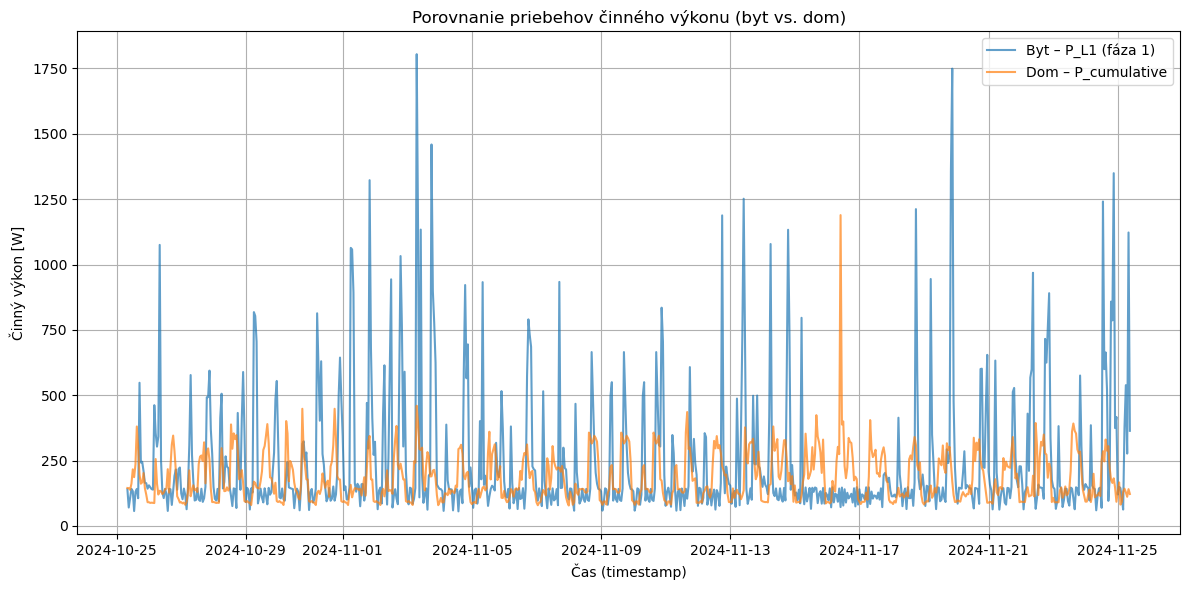

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Prvý dataset (napr. byt – len jedna fáza)
plt.plot(df.index, df['P_L1'], label='Byt – P_L1 (fáza 1)', alpha=0.7)

# Druhý dataset (napr. dom – celková spotreba)
plt.plot(df2.index, df2['P_cumulative'], label='Dom – P_cumulative', alpha=0.7)

plt.title('Porovnanie priebehov činného výkonu (byt vs. dom)')
plt.xlabel('Čas (timestamp)')
plt.ylabel('Činný výkon [W]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Funkcia clip_extremes_inplace orezáva extrémne hodnoty v každom stĺpci podľa zadaných kvantilov (napr. 0.5 % a 99.5 %). Hodnoty pod dolným kvantilom nahradí dolným limitom a hodnoty nad horným kvantilom horným limitom.

In [70]:
def clip_extremes_inplace(df, lower_q=0.005, upper_q=0.995):
    for col in df.columns:
        lower = df[col].quantile(lower_q)
        upper = df[col].quantile(upper_q)
        df[col] = df[col].clip(lower=lower, upper=upper)


In [72]:
clip_extremes_inplace(df2)

### Vizualizacia priebeu domu po odstraneni vykyvu

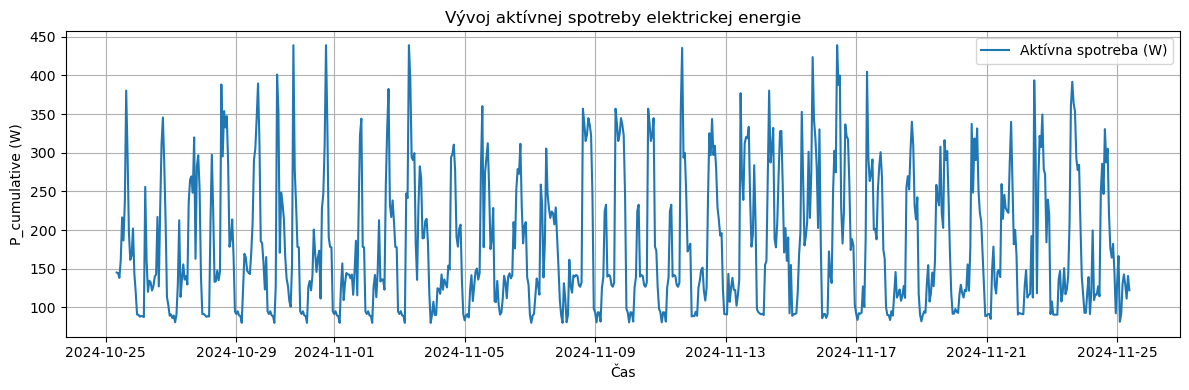

In [74]:
plt.figure(figsize=(12, 4))
plt.plot(df2.index, df2['P_cumulative'], label='Aktívna spotreba (W)')
plt.title('Vývoj aktívnej spotreby elektrickej energie')
plt.xlabel('Čas')
plt.ylabel('P_cumulative (W)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Vizualizacie porovnani medzi jednotlivymi fazami

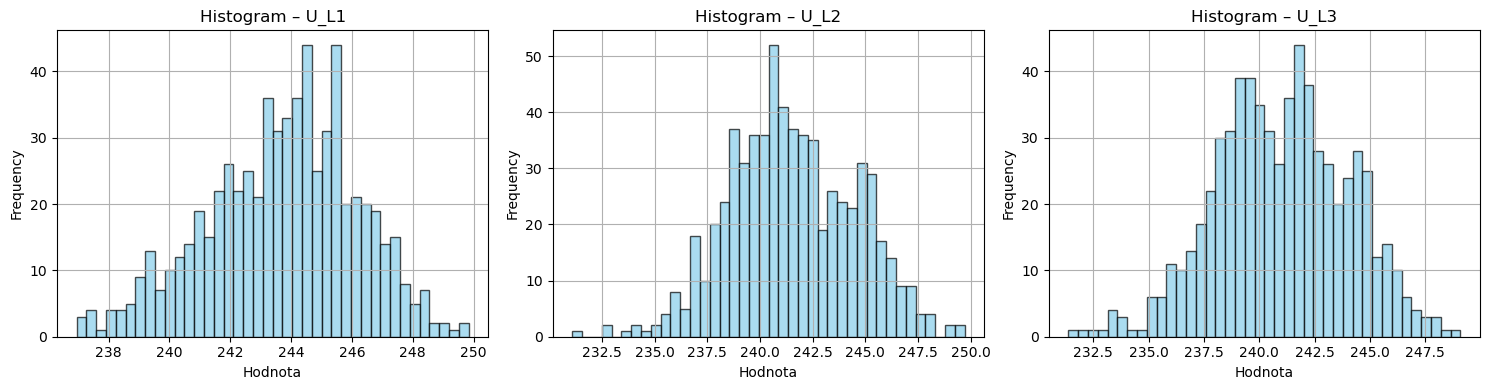

In [79]:
import matplotlib.pyplot as plt

# Vybrané atribúty pre napätie na 3 fázach
columns = ['U_L1', 'U_L2', 'U_L3']

# Nastavenie vizualizácie
plt.figure(figsize=(15, 4))

for i, col in enumerate(columns):
    plt.subplot(1, 3, i + 1)
    df2[col].plot(kind='hist', bins=40, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title(f'Histogram – {col}')
    plt.xlabel('Hodnota')
    plt.grid(True)

plt.tight_layout()
plt.show()


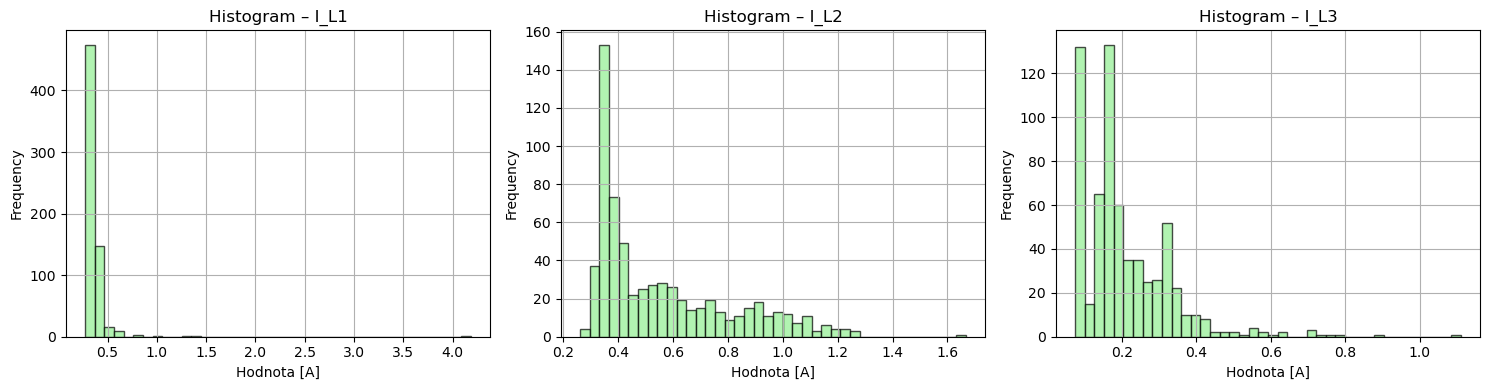

In [81]:
import matplotlib.pyplot as plt

# Prúdy na troch fázach
current_columns = ['I_L1', 'I_L2', 'I_L3']

plt.figure(figsize=(15, 4))

for i, col in enumerate(current_columns):
    plt.subplot(1, 3, i + 1)
    df2[col].plot(kind='hist', bins=40, alpha=0.7, color='lightgreen', edgecolor='black')
    plt.title(f'Histogram – {col}')
    plt.xlabel('Hodnota [A]')
    plt.grid(True)

plt.tight_layout()
plt.show()


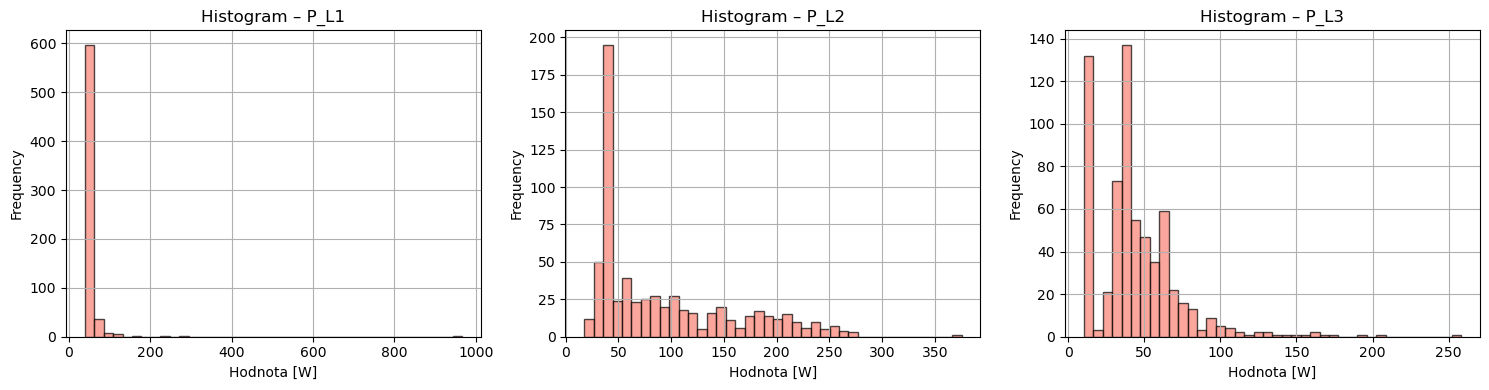

In [83]:
# Výkony na troch fázach
power_columns = ['P_L1', 'P_L2', 'P_L3']

plt.figure(figsize=(15, 4))

for i, col in enumerate(power_columns):
    plt.subplot(1, 3, i + 1)
    df2[col].plot(kind='hist', bins=40, alpha=0.7, color='salmon', edgecolor='black')
    plt.title(f'Histogram – {col}')
    plt.xlabel('Hodnota [W]')
    plt.grid(True)

plt.tight_layout()
plt.show()

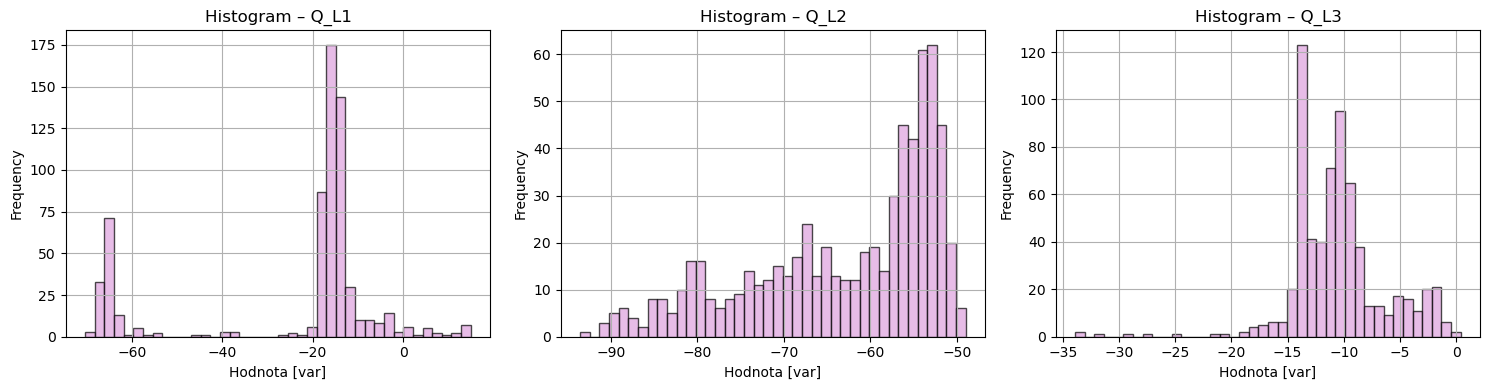

In [85]:
import matplotlib.pyplot as plt

# Jalové výkony na troch fázach
q_columns = ['Q_L1', 'Q_L2', 'Q_L3']

plt.figure(figsize=(15, 4))

for i, col in enumerate(q_columns):
    plt.subplot(1, 3, i + 1)
    df2[col].plot(kind='hist', bins=40, alpha=0.7, color='plum', edgecolor='black')
    plt.title(f'Histogram – {col}')
    plt.xlabel('Hodnota [var]')
    plt.grid(True)

plt.tight_layout()
plt.show()


### Vizualizacie porovnani medzi domom a bytom

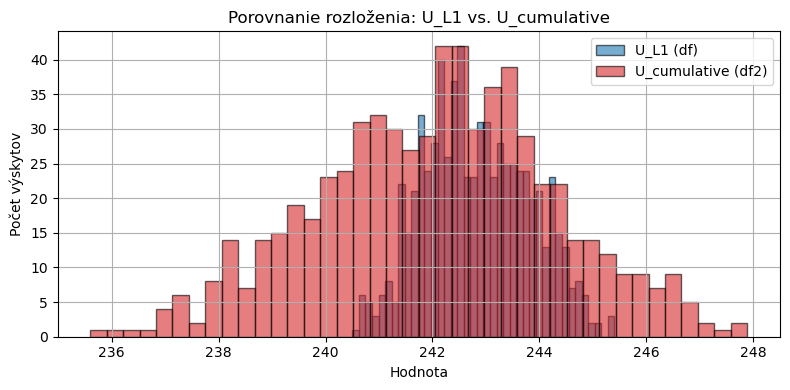

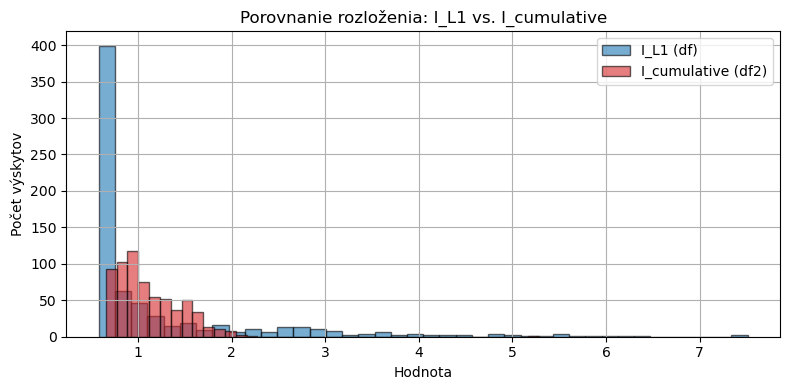

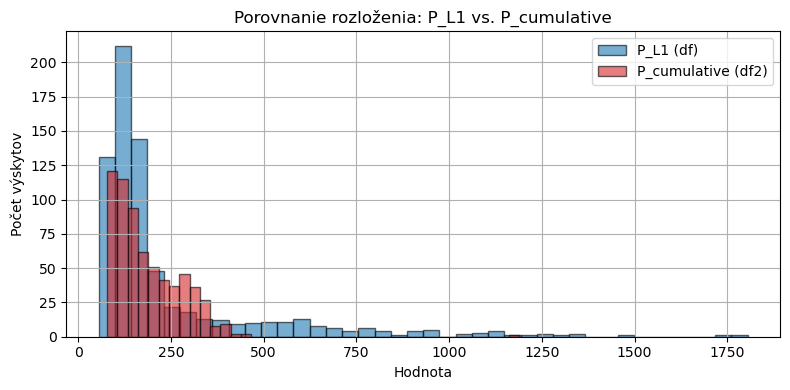

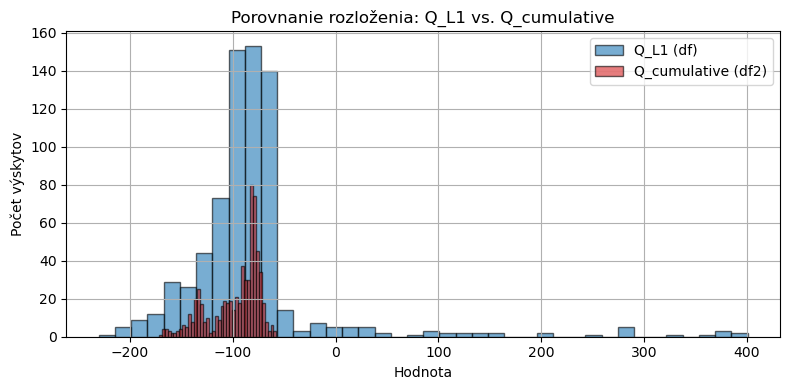

In [89]:
import matplotlib.pyplot as plt

# Dvojice stĺpcov na porovnanie (fáza 1 vs. cumulative)
compare_columns = [
    ('U_L1', 'U_cumulative'),
    ('I_L1', 'I_cumulative'),
    ('P_L1', 'P_cumulative'),
    ('Q_L1', 'Q_cumulative')
]

# Nové kontrastné farby
color_df = '#1f77b4'    # sýta modrá pre df
color_df2 = '#d62728'   # sýta červená pre df2

# Vykreslenie
for col_df, col_df2 in compare_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col_df], bins=40, alpha=0.6, label=f'{col_df} (df)', color=color_df, edgecolor='black')
    plt.hist(df2[col_df2], bins=40, alpha=0.6, label=f'{col_df2} (df2)', color=color_df2, edgecolor='black')
    plt.title(f'Porovnanie rozloženia: {col_df} vs. {col_df2}')
    plt.xlabel('Hodnota')
    plt.ylabel('Počet výskytov')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Dekompozicia casoveho radu

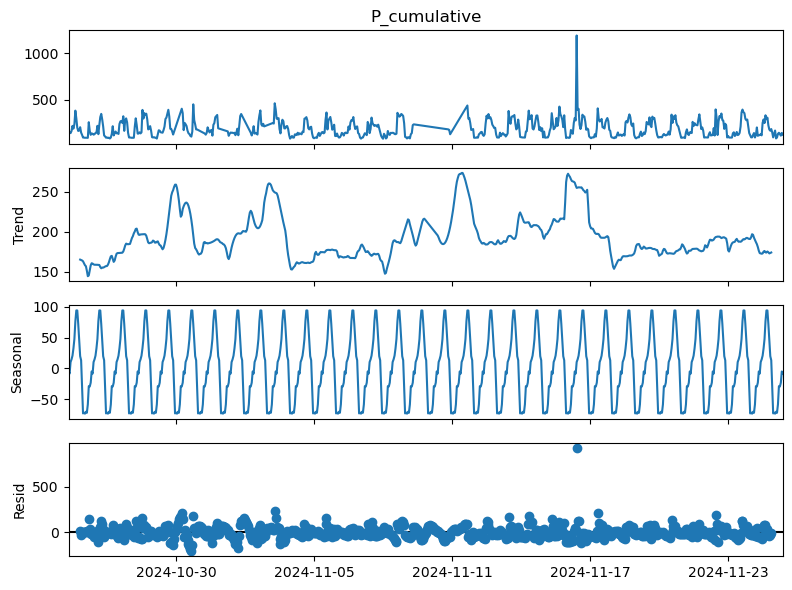

In [124]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# dekompozícia
result = seasonal_decompose(df2['P_cumulative'], model='additive', period=24)

# vykreslenie s obmedzením xtickov
fig = result.plot()
fig.set_size_inches(8, 6)

# iteruj cez všetky osi a nastav menej xtickov
for ax in fig.axes:
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))  # max 6 popisov na osi X

plt.tight_layout()
plt.show()


### Korelacna matica 

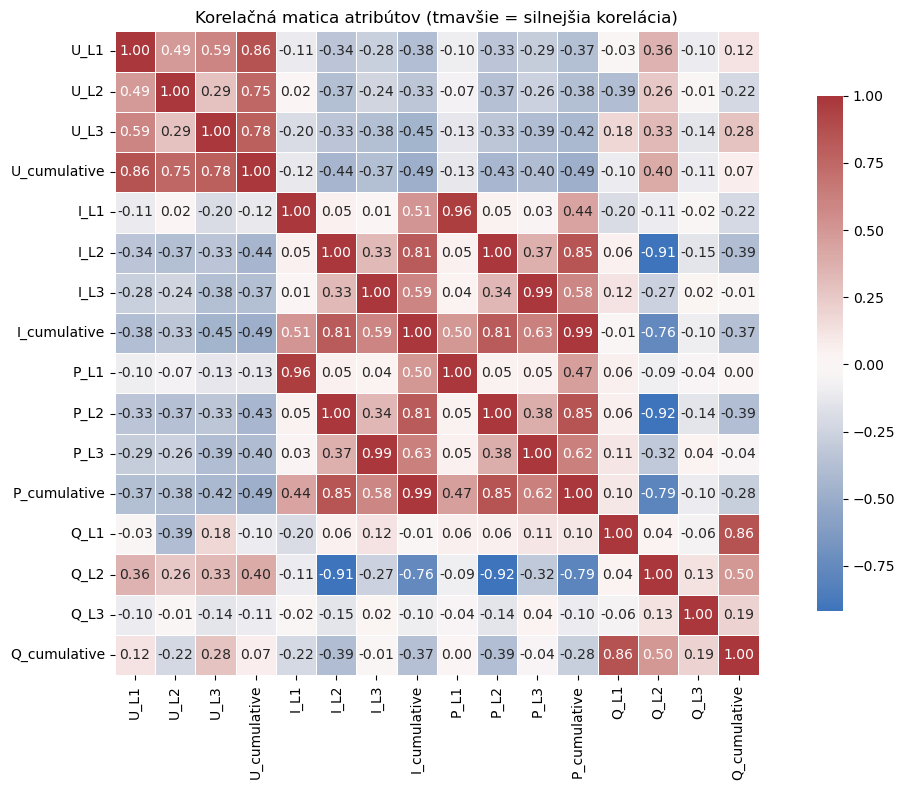

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

# Korelačná matica
corr_matrix = df2.corr()

# Vykreslenie s upravenou farebnou mapou
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Korelačná matica atribútov (tmavšie = silnejšia korelácia)")
plt.tight_layout()
plt.show()


### Vytvorenie novych atributov

In [95]:



df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek  # 0 = pondelok, 6 = nedeľa
df['day'] = df.index.day
df['month'] = df.index.month
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)  # sobota alebo nedeľa = 1


df2['hour'] = df2.index.hour
df2['day_of_week'] = df2.index.dayofweek  # 0 = pondelok, 6 = nedeľa
df2['day'] = df2.index.day
df2['month'] = df2.index.month
df2['is_weekend'] = df2['day_of_week'].isin([5, 6]).astype(int)  # víkend = 1



In [106]:
df['lag_1'] = df['P_L1'].shift(1) # oneskorenie cielovej premennej o hodinu
df['lag_24'] = df['P_L1'].shift(24) # oneskorenie cielovej premennej o 24 hodin


In [164]:
df2['lag_1'] = df2['P_cumulative'].shift(1) # oneskorenie cielovej premennej o hodinu
df2['lag_24'] = df2['P_cumulative'].shift(24)  # oneskorenie cielovej premennej o 24 hodin

In [166]:
print(df2.dtypes) # zobrazenie typov atributov

U_L1            float64
U_L2            float64
U_L3            float64
U_cumulative    float64
I_L1            float64
I_L2            float64
I_L3            float64
I_cumulative    float64
P_L1            float64
P_L2            float64
P_L3            float64
P_cumulative    float64
Q_L1            float64
Q_L2            float64
Q_L3            float64
Q_cumulative    float64
hour              int32
day_of_week       int32
day               int32
month             int32
is_weekend        int32
lag_1           float64
lag_2           float64
lag_3           float64
rolling_3h      float64
dtype: object


In [183]:
from statsmodels.tsa.stattools import pacf

# Získa hodnoty PACF (napr. pre prvých 30 lagov)
pacf_values = pacf(df2['P_cumulative'], nlags=30)

# Vytvorime zoznam dvojíc (lag, abs(hodnota))
pacf_abs = [(lag, abs(value)) for lag, value in enumerate(pacf_values)]

# Zoradíme podľa absolútnej hodnoty zostupne
pacf_sorted = sorted(pacf_abs, key=lambda x: x[1], reverse=True)

# Vypíšeme zoradený zoznam
print("Zoradené lagy podľa absolútnej hodnoty PACF:")
for lag, value in pacf_sorted:
    print(f"Lag {lag}: {value:.4f}")


Zoradené lagy podľa absolútnej hodnoty PACF:
Lag 0: 1.0000
Lag 1: 0.7471
Lag 24: 0.2034
Lag 20: 0.1775
Lag 23: 0.1721
Lag 4: 0.1604
Lag 12: 0.1353
Lag 5: 0.1336
Lag 14: 0.1177
Lag 22: 0.1144
Lag 11: 0.1133
Lag 16: 0.1097
Lag 6: 0.0878
Lag 15: 0.0870
Lag 2: 0.0867
Lag 9: 0.0825
Lag 19: 0.0816
Lag 21: 0.0778
Lag 10: 0.0694
Lag 8: 0.0628
Lag 7: 0.0610
Lag 27: 0.0570
Lag 13: 0.0550
Lag 25: 0.0547
Lag 17: 0.0528
Lag 30: 0.0230
Lag 26: 0.0155
Lag 3: 0.0132
Lag 28: 0.0105
Lag 29: 0.0087
Lag 18: 0.0083


In [125]:
df2 = df2.dropna()  # Odstráni všetky riadky z DataFrame df2, ktoré obsahujú aspoň jednu chýbajúcu hodnotu (NaN)
df = df.dropna()    # To isté urobí pre DataFrame df – odstráni riadky s chýbajúcimi hodnotami


### Vizualizacia porovnania vypocitaneho a odmeraneho cinneho vykonu

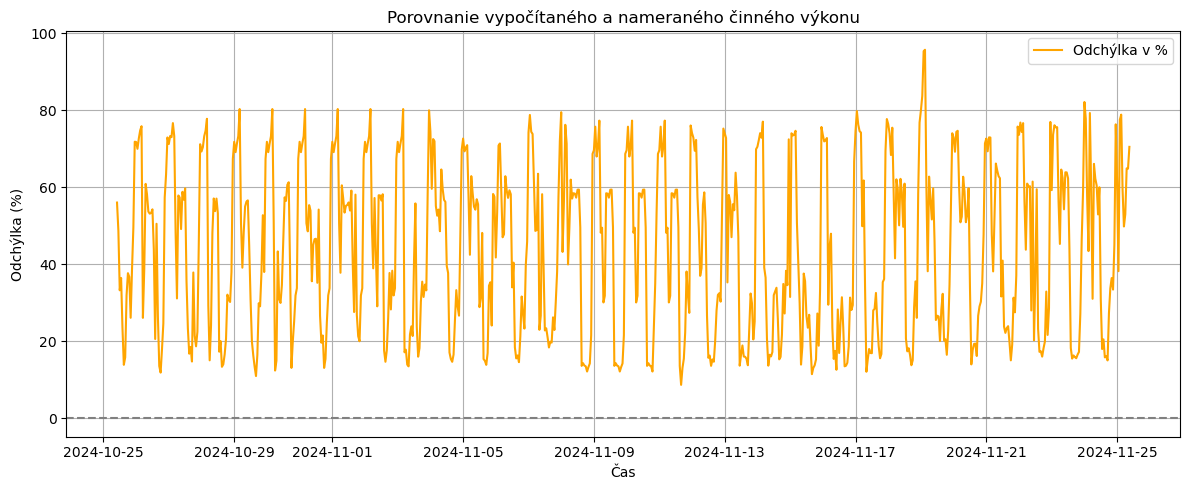

 Najväčšia odchýlka: 95.77 %
 Najmenšia odchýlka: 8.69 %


In [152]:
import numpy as np
import matplotlib.pyplot as plt

def analyzuj_odchylky(df2):
    df = df2.copy()

    # Výpočet teoretického činného výkonu
    df['P_vypocitany'] = np.sqrt((df['U_cumulative'] * df['I_cumulative'])**2 - df['Q_cumulative']**2)

    # Odstránenie prípadných chýb (negatívna hodnota pod odmocninou, inf, nan)
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['P_vypocitany', 'P_cumulative'])

    # Výpočet rozdielu (odchýlky) v percentách
    df['odchylka_percent'] = 100 * (df['P_vypocitany'] - df['P_cumulative']) / df['P_cumulative']

    # Vizualizácia odchýlok
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df['odchylka_percent'], label='Odchýlka v %', color='orange')
    plt.axhline(0, color='gray', linestyle='--')
    plt.title('Porovnanie vypočítaného a nameraného činného výkonu')
    plt.xlabel('Čas')
    plt.ylabel('Odchýlka (%)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Výpis extrémnych odchýlok
    max_odch = df['odchylka_percent'].max()
    min_odch = df['odchylka_percent'].min()
    print(f" Najväčšia odchýlka: {max_odch:.2f} %")
    print(f" Najmenšia odchýlka: {min_odch:.2f} %")

    return df[['P_cumulative', 'P_vypocitany', 'odchylka_percent']]

#  Spustenie:
vysledky = analyzuj_odchylky(df2)


### Korelacna matica novovytvorenych atributov 

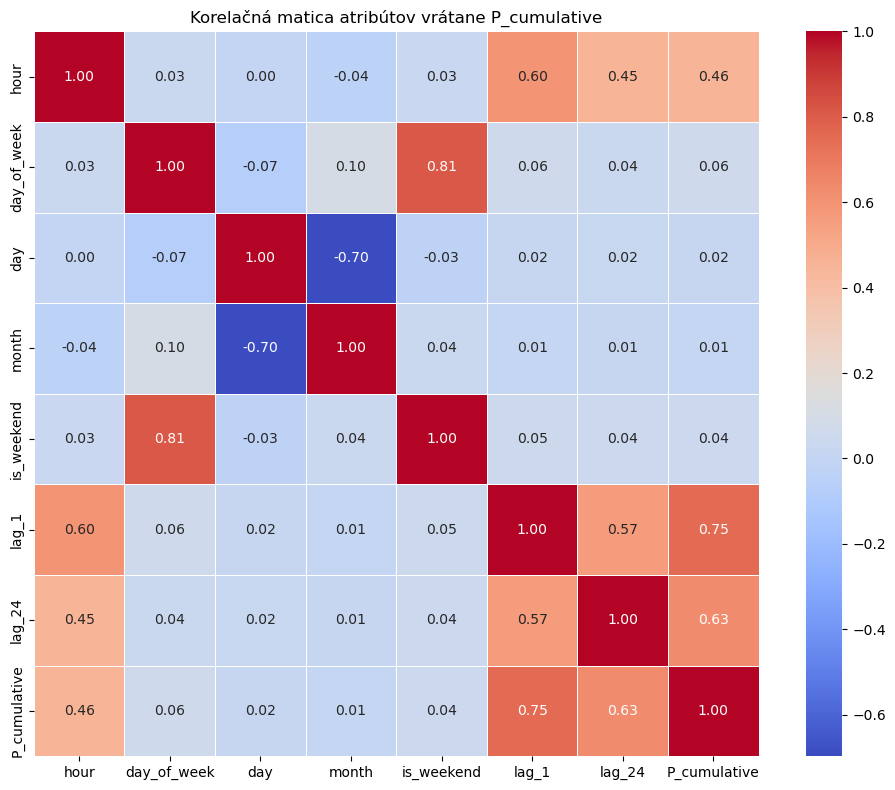

In [167]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#  Cieľová premenná
target_col = 'P_cumulative'

#  Zoznam vstupných atribútov
feature_cols = [
    'hour', 'day_of_week', 'day', 'month', 'is_weekend',
    'lag_1', 'lag_24'
]

#  Odstránenie riadkov s chýbajúcimi hodnotami
df_clean = df2[feature_cols + [target_col]].dropna()

#  Výpočet celej korelačnej matice
correlation_matrix = df_clean.corr()

#  Vizuálne zobrazenie heatmapy
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)
plt.title("Korelačná matica atribútov vrátane P_cumulative")
plt.tight_layout()
plt.show()
